<a href="https://colab.research.google.com/github/ganesh10-code/DL_Lab/blob/main/Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-8
19. Google Inception Module

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 186ms/step - accuracy: 0.2321 - loss: 2.2746 - val_accuracy: 0.4820 - val_loss: 1.5287
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - accuracy: 0.4772 - loss: 1.5250 - val_accuracy: 0.5260 - val_loss: 1.4043
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - accuracy: 0.5597 - loss: 1.3123 - val_accuracy: 0.5400 - val_loss: 1.3540
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.5728 - loss: 1.2310 - val_accuracy: 0.5490 - val_loss: 1.3296
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.6026 - loss: 1.1614 - val_accuracy: 0.5570 - val_loss: 1.3283
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.6115 - loss: 1.1288 - val_accuracy: 0.5670 - val_loss: 1.3068
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.6287 - loss: 1.0776 - val_accuracy: 0.5640 - val_loss: 1.3153
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - accuracy: 0.6270 - loss: 1

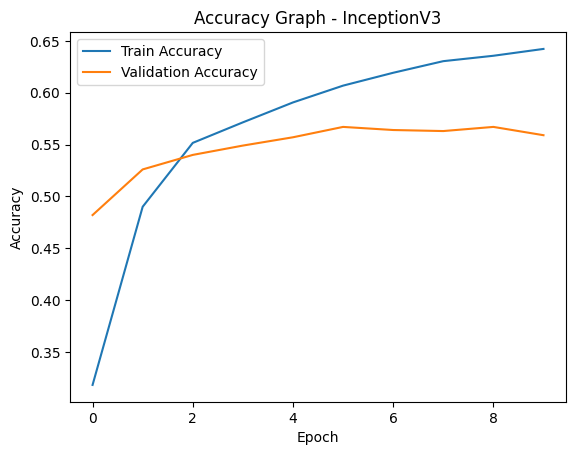

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step


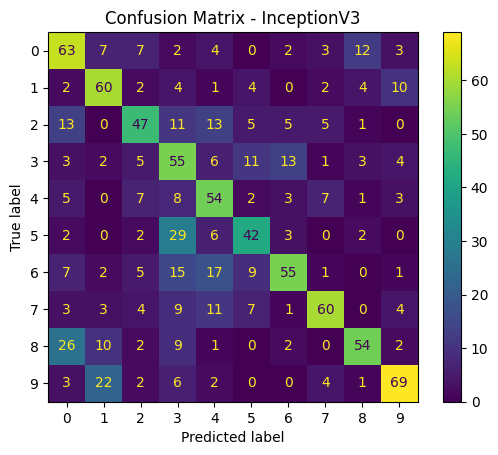

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.5625 - loss: 1.3742
Test Accuracy: 0.5590000152587891


In [ ]:
# Implementing Google Inception Module with pre-defined model(InceptionV3)
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# -------------------------
# Parameters
# -------------------------
IMG_SIZE = 75
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 10

# -------------------------
# Load CIFAR-10
# -------------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# smaller subset for faster demo
X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1000]
y_test = y_test[:1000]

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# resize for InceptionV3
X_train = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

# one-hot encoding
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# -------------------------
# Pretrained Model
# -------------------------
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------
# Train
# -------------------------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# -------------------------
# Accuracy Graph
# -------------------------
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Graph - InceptionV3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------
# Confusion Matrix
# -------------------------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - InceptionV3")
plt.show()

# -------------------------
# Evaluate
# -------------------------
loss, acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", acc)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 435ms/step - accuracy: 0.1382 - loss: 2.2303 - val_accuracy: 0.1490 - val_loss: 2.1566
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 438ms/step - accuracy: 0.2193 - loss: 2.0535 - val_accuracy: 0.2300 - val_loss: 2.0092
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 436ms/step - accuracy: 0.2384 - loss: 1.9952 - val_accuracy: 0.2620 - val_loss: 1.9407
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 437ms/step - accuracy: 0.2602 - loss: 1.9357 - val_accuracy: 0.2910 - val_loss: 1.9049
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 437ms/step - accuracy: 0.2734 - loss: 1.9023 - val_accuracy: 0.3300 - val_loss: 1.8191
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 437ms/step - accuracy: 0.2936 - loss: 1.8340 - val_accuracy: 0.3540 - val_loss: 1.7740
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 443ms/step - accuracy: 0.3312 - loss: 1.7889 - val_accuracy: 0.3630 - val_loss: 1.7356
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 433ms/step - accuracy: 0.3484 - loss: 1

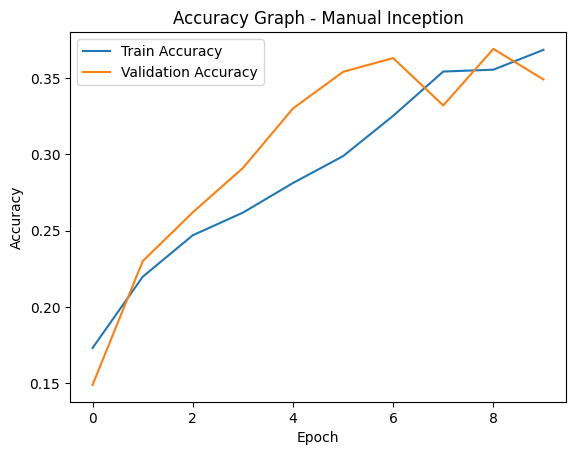

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step


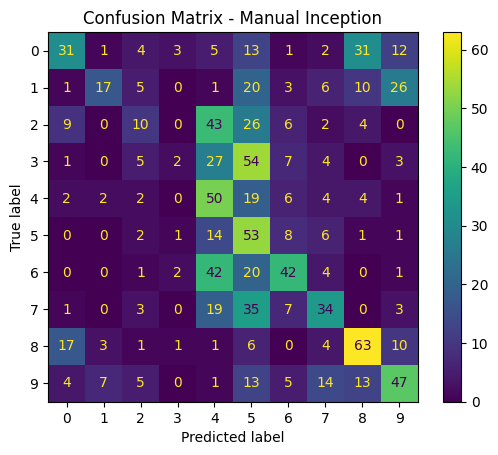

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3544 - loss: 1.7046
Test Accuracy: 0.3490000069141388


In [ ]:
# Implementing Google Inception Module without pre-defined model
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

# -------------------------
# Parameters
# -------------------------
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 10

# -------------------------
# Load CIFAR-10
# -------------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# smaller subset
X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1000]
y_test = y_test[:1000]

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# resize
X_train = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

# one-hot encoding
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# -------------------------
# Inception Module
# -------------------------
def inception_module(x):

    branch1 = layers.Conv2D(32, (1,1), padding='same', activation='relu')(x)

    branch2 = layers.Conv2D(32, (1,1), padding='same', activation='relu')(x)
    branch2 = layers.Conv2D(64, (3,3), padding='same', activation='relu')(branch2)

    branch3 = layers.Conv2D(16, (1,1), padding='same', activation='relu')(x)
    branch3 = layers.Conv2D(32, (5,5), padding='same', activation='relu')(branch3)

    branch4 = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    branch4 = layers.Conv2D(32, (1,1), padding='same', activation='relu')(branch4)

    output = layers.concatenate([branch1, branch2, branch3, branch4])

    return output

# -------------------------
# Build Model
# -------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = inception_module(x)
x = inception_module(x)

x = layers.MaxPooling2D((2,2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# Train
# -------------------------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# -------------------------
# Accuracy Graph
# -------------------------
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Graph - Manual Inception")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------
# Confusion Matrix
# -------------------------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Manual Inception")
plt.show()

# -------------------------
# Evaluate
# -------------------------
loss, acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", acc)